In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_parquet('../Data/Credit_Cluster.parquet')
df.head()

,cust_id,balance,balance_frequency,purchases,oneoff_purchases,installments_purchases,cash_advance,purchases_frequency,oneoff_purchases_frequency,purchases_installments_frequency,...,cash_advance_trx,purchases_trx,credit_limit,payments,minimum_payments,prc_full_payment,tenure,cluster,snapshot_date,cluster_id
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,...,0,2,1000.0,201.802084,139.509787,0.000000,12,The Budget/Eco Shoppers,2026-07-05,3
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,...,4,0,7000.0,4103.032597,1072.340217,0.222222,12,The Inactive / Cash Borrowers,2026-07-05,2
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,...,0,12,7500.0,622.066742,627.284787,0.000000,12,The VIP Power Spenders,2026-07-05,1
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,...,0,1,1200.0,678.334763,244.791237,0.000000,12,The Inactive / Cash Borrowers,2026-07-05,2
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,...,0,8,1800.0,1400.057770,2407.246035,0.000000,12,The VIP Power Spenders,2026-07-05,1


In [3]:
sns.set_theme(style='whitegrid')
plt.rcParamsDefault['figure.figsize'] = [10,6]

- Giả định 1 (Nhóm Khách hàng Cao cấp): Những khách hàng có BALANCE cao và PRC_FULL_PAYMENT cao (>80%) là nhóm có thu nhập cao, chi tiêu nhiều nhưng không muốn trả lãi.
→ Hướng xử lý: Cần kiểm chứng xem nhóm này có thực sự mang lại nhiều phí giao dịch (PURCHASES) cho ngân hàng không.


Validate Assumtion 1
Average spending level for each cluster
                          cluster    purchases
0  The Balanced Installment Users  1333.785197
1         The Budget/Eco Shoppers   454.516935
2   The Inactive / Cash Borrowers    29.360745
3          The VIP Power Spenders  2609.463523

Number of customers who have made full payment (>80%): 755 customers
They are concentrated in clusters with a rate of:
cluster
The Budget/Eco Shoppers           54.172185
The VIP Power Spenders            43.046358
The Inactive / Cash Borrowers      1.854305
The Balanced Installment Users     0.927152
Name: proportion, dtype: float64


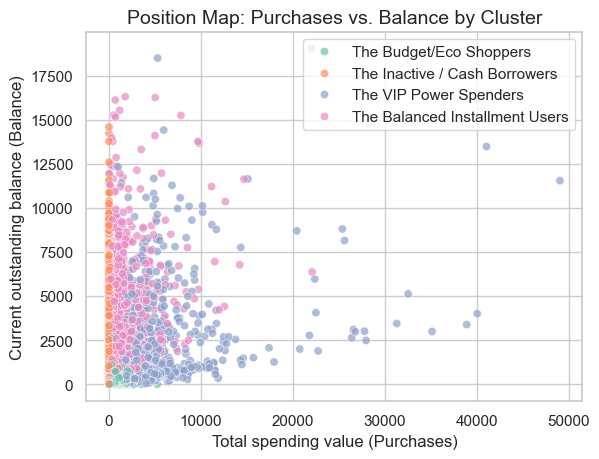

In [4]:
print('Validate Assumtion 1')

# Tinh toan chi tieu (purchase) trung binh cua tung cum de so sanh
avg_purchase =  df.groupby('cluster')['purchases'].mean().reset_index()
print('Average spending level for each cluster')
print(avg_purchase)

#Loc rieng nhom full_payment de xem ho nam o cum nao nhieu nhat
full_payers = df[df['prc_full_payment'] >=0.8]
print(f'\nNumber of customers who have made full payment (>80%): {len(full_payers)} customers')
print('They are concentrated in clusters with a rate of:')
print(full_payers['cluster'].value_counts(normalize=True) * 100)

#Ve bieu do phan tan
plt.figure()
sns.scatterplot(
    data = df,
    x = 'purchases',
    y = 'balance',
    hue = 'cluster',
    palette= 'Set2',
    alpha = 0.7
)
plt.title('Position Map: Purchases vs. Balance by Cluster', fontsize = 14)
plt.xlabel('Total spending value (Purchases)')
plt.ylabel('Current outstanding balance (Balance)')
plt.legend()
plt.show()

- Chi tiêu vượt trội (Vùng bên phải trục X): Nhóm màu xanh dương kéo một dải rất dài sang phía bên phải, trải từ mức $10,000$ đến tận gần $50,000$ tiền chi tiêu. Trong khi tất cả các cụm khác đều bị nghẽn lại ở mức dưới $15,000$. Điều này chứng minh phần đầu tiên của giả định hoàn toàn đúng: Đây chính là động cơ thúc đẩy doanh số quẹt thẻ chính, mang lại nguồn thu phí giao dịch khổng lồ cho ngân hàng.
- vùng đáy của trục Y (Dư nợ sát mốc 0 đến dưới $2,500$), có một lượng rất lớn các chấm xanh dương tập trung dày đặc ở đây, kéo dài suốt trục chi tiêu lớn. Đây chính là minh chứng cho nhóm "Chi tiêu cực nhiều nhưng tất toán ngay cuối kỳ" (PRC_FULL_PAYMENT cao) mà bạn đã giả định — họ quẹt thẻ để tận dụng ưu đãi hoặc dòng tiền chứ không để tích lũy nợ chịu lãi.
- Tuy nhiên, biểu đồ cũng chỉ ra một góc nhìn mới: Có một phần khách hàng VIP vẫn tích lũy dư nợ rất cao (vùng từ $5,000$ đến hơn $12,500$ trên trục Y). Nhóm này vừa chi tiêu nhiều vừa ôm nợ lớn, có thể họ đang tận dụng hạn mức cao để đầu tư hoặc kinh doanh.

In [5]:
# Lọc riêng cụm VIP (The VIP Power Spenders)
# Bạn thay thế tên biến 'cluster' bằng tên cột cụm chính xác của bạn nếu có thay đổi
vip_cluster_id = df[df['cluster'] == 'The VIP Power Spenders']['cluster'].iloc[0]
df_vip = df[df['cluster'] == vip_cluster_id]

# 1. Tính chi tiêu trung bình và dư nợ trung bình của cụm VIP so với toàn danh mục
avg_purchases_vip = df_vip['purchases'].mean()
avg_purchases_all = df['purchases'].mean()

print(f"Average spending of the VIP segment: ${avg_purchases_vip:,.2f}")
print(f"Average spend across the entire portfolio: ${avg_purchases_all:,.2f}")
print(f"--> VIP customers' urgent spending {avg_purchases_vip/avg_purchases_all:.1f} ordinary people!\n")

# 2. Đếm xem bao nhiêu % khách VIP có tỷ lệ tất toán nợ (prc_full_payment) > 80%
vip_full_payers = df_vip[df_vip['prc_full_payment'] >= 0.8]
pct_vip_full_pay = (len(vip_full_payers) / len(df_vip)) * 100

print(f"Percentage of VIP customers paying off their debt in full (>80%): {pct_vip_full_pay:.2f}%")
print(f"Average spending of this VIP group that does not incur interest: ${vip_full_payers['purchases'].mean():,.2f}")

Average spending of the VIP segment: $2,609.46
Average spend across the entire portfolio: $1,025.43
--> VIP customers' urgent spending 2.5 ordinary people!

Percentage of VIP customers paying off their debt in full (>80%): 15.03%
Average spending of this VIP group that does not incur interest: $4,027.27


- Giả định 2 (Nhóm Rút tiền mặt): Khách hàng có CASH_ADVANCE_FREQUENCY cao thường có PRC_FULL_PAYMENT thấp và MINIMUM_PAYMENTS cao.
→ Hướng xử lý: Kiểm tra mối tương quan xem đây có phải là nhóm khách hàng rủi ro cao (Subprime) nhưng mang lại biên lợi nhuận lãi vay lớn hay không.


- Bám chặt trục tung (Vùng bên trái sát mốc 0 của trục X): Toàn bộ các chấm màu cam tập trung thành một đường thẳng đứng đứng sát sạt mốc $0$ của trục Purchases. Điều này chứng minh họ gần như không quẹt thẻ để mua sắm thông thường. Thẻ tín dụng đối với họ chỉ có một công năng duy nhất: Một công cụ vay tiền mặt nhanh.
- Tích lũy dư nợ lớn (Balance cao): Dù chi tiêu mua sắm bằng $0$, nhưng các chấm màu cam lại kéo dài từ đáy lên tới mức dư nợ hơn $15,000$ trên trục Y. Điều này chứng minh số dư nợ hiện tại của họ (Current outstanding balance) hoàn toàn được hình thành từ các khoản rút tiền mặt (Cash Advance) tích tụ qua nhiều kỳ mà chưa thể tất toán.

Validate Assumtion 2

Cross-Cluster Financial Behavior Analysis:
                                Avg_Cash_Advance_Freq  Avg_Full_Payment_Rate  Avg_Min_Payment_Amount  Avg_Cash_Advance_Amount  Avg_Outstanding_Balance
cluster                                                                                                                                               
The Balanced Installment Users               0.334899               0.036936             1500.073099              2567.233877              3205.086043
The Budget/Eco Shoppers                      0.007214               0.279832              261.063286                23.205879               248.371942
The Inactive / Cash Borrowers                0.271459               0.035100             1034.152132              1925.805842              2179.460171
The VIP Power Spenders                       0.009476               0.237378              962.073422                41.984273              1478.821977

--- TARGET CLUSTER PORTFOLIO

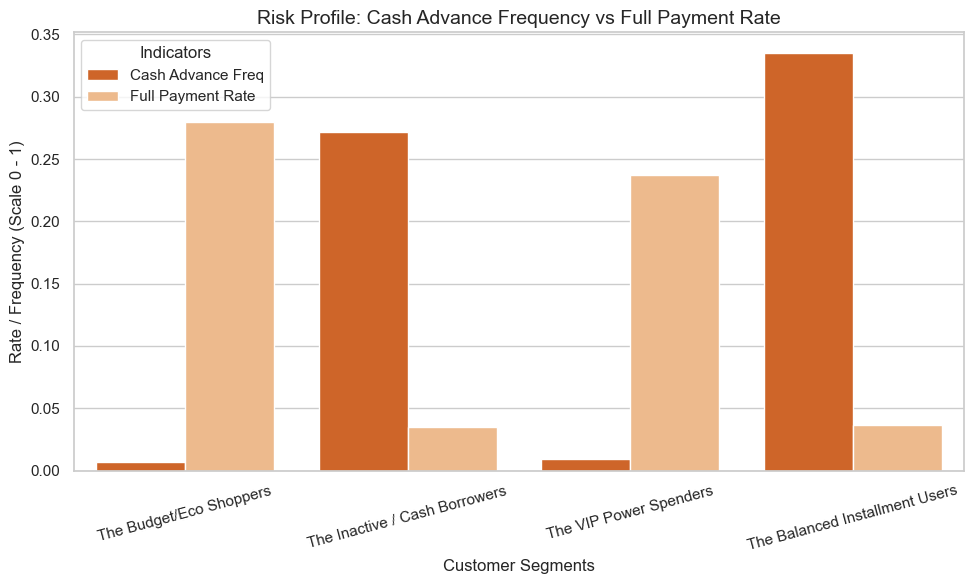

In [7]:
print('Validate Assumtion 2')

# define cluster names 
target_cluster_name = 'The Inactive / Cash Borrowers'

# Extract finacial metrics to evaluate risk and profit potencial
# We use 'cash_advance' and 'balance' as proxies for interest-bearing revenue
metrics_to_analyze = [
    'cash_advance_frequency', 
    'prc_full_payment', 
    'minimum_payments', 
    'cash_advance',
    'balance'
]

# compute the average values for each clustes to compare
cluster_comparison = df.groupby('cluster')[metrics_to_analyze].mean().rename(columns = {
    'cash_advance_frequency': 'Avg_Cash_Advance_Freq',
    'prc_full_payment': 'Avg_Full_Payment_Rate',
    'minimum_payments': 'Avg_Min_Payment_Amount',
    'cash_advance': 'Avg_Cash_Advance_Amount',
    'balance': 'Avg_Outstanding_Balance'
})
print("\nCross-Cluster Financial Behavior Analysis:")
print(cluster_comparison.to_string())

# calculate the financial contribution of the target cluster to the portfolio
total_bank_cash_advance = df['cash_advance'].sum()
total_bank_balance = df['balance'].sum()

df_target_cluster = df[df['cluster'] == target_cluster_name]
target_cash_advance_sum = df_target_cluster['cash_advance'].sum()
target_balance_sum = df_target_cluster['balance'].sum()

share_of_cash_advance = (target_cash_advance_sum / total_bank_cash_advance) * 100
share_of_total_balance = (target_balance_sum / total_bank_balance) * 100


print("\n--- TARGET CLUSTER PORTFOLIO CONTRIBUTION ---")
print(f"Target Cluster: {target_cluster_name}")
print(f"Share of Total Cash Advance Volume: {share_of_cash_advance:.2f}%")
print(f"Share of Total Outstanding Balance: {share_of_total_balance:.2f}%")

#Visualizing the constrast: Cash Advance Frequncy as Full Payment Rate
plt.figure(figsize=(10,6))
df_melted_risk = pd.melt(
    df,
    id_vars=['cluster'],
    value_vars=['cash_advance_frequency', 'prc_full_payment'],
    var_name='Risk_Indicator', 
    value_name='Value'
)

sns.barplot(
    data=df_melted_risk, 
    x='cluster', 
    y='Value', 
    hue='Risk_Indicator', 
    palette='Oranges_r',
    errorbar=None
)

plt.title('Risk Profile: Cash Advance Frequency vs Full Payment Rate', fontsize=14)
plt.xlabel('Customer Segments')
plt.ylabel('Rate / Frequency (Scale 0 - 1)')
plt.xticks(rotation=15)
plt.legend(title='Indicators', labels=['Cash Advance Freq', 'Full Payment Rate'])
plt.tight_layout()
plt.show()

--- HYPOTHESIS 3 VALIDATION: THE INSTALLMENT USERS ---
Overall Correlation Matrix:
                        installments_purchases  purchases_frequency    tenure
installments_purchases                1.000000             0.441193  0.083346
purchases_frequency                   0.441193             1.000000  0.052161
tenure                                0.083346             0.052161  1.000000

Engagement and Loyalty Profiles Across Clusters:
                                Avg_Installment_Purchases  Avg_Purchase_Frequency  Avg_Tenure_Months
cluster                                                                                             
The Balanced Installment Users                 550.928650                0.676584          11.487788
The Budget/Eco Shoppers                        322.648406                0.554481          11.413313
The Inactive / Cash Borrowers                    2.281586                0.024479          11.392547
The VIP Power Spenders                         916

C:\Users\Asus\AppData\Local\Temp\ipykernel_10340\1030913402.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


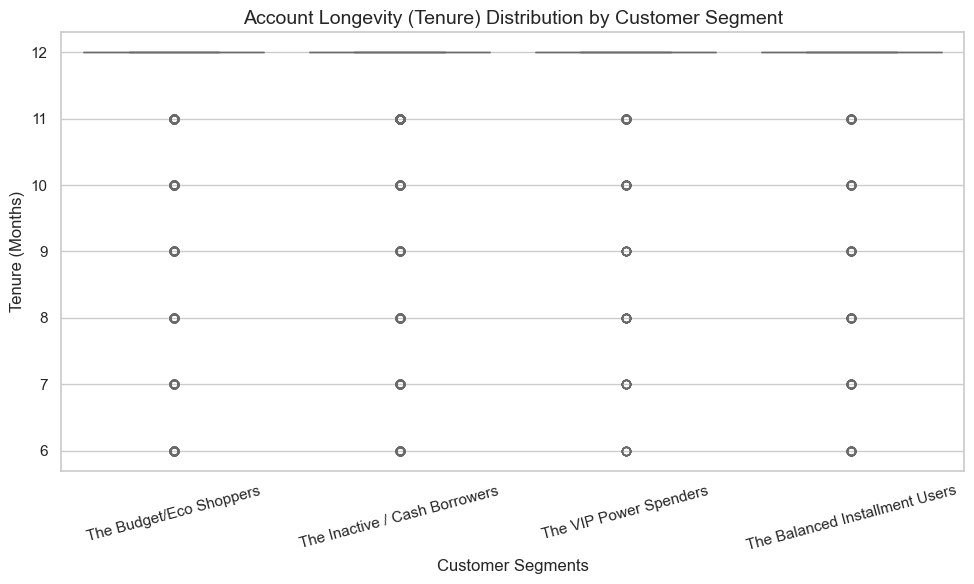

C:\Users\Asus\AppData\Local\Temp\ipykernel_10340\1030913402.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


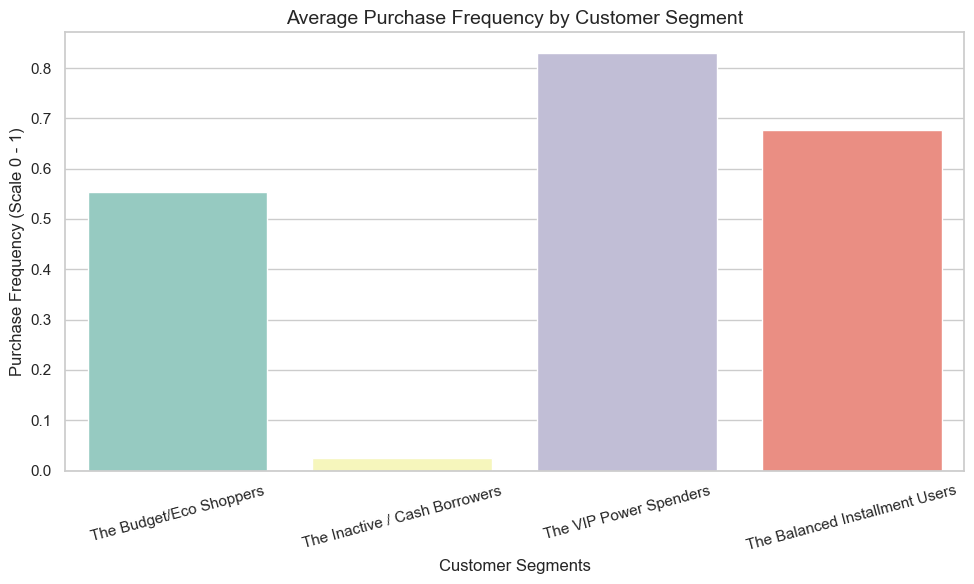

In [10]:


print("--- HYPOTHESIS 3 VALIDATION: THE INSTALLMENT USERS ---")

# 1. Calculate overall correlation to see if higher installments mean higher loyalty/engagement
correlation_matrix = df[['installments_purchases', 'purchases_frequency', 'tenure']].corr()
print("Overall Correlation Matrix:")
print(correlation_matrix.to_string())

# 2. Extract metrics specifically for the group with high installment behavior
# Comparing 'The Balanced Installment Users' against other segments
engagement_metrics = [
    'installments_purchases',
    'purchases_frequency',
    'tenure'
]

cluster_engagement = df.groupby('cluster')[engagement_metrics].mean().rename(columns={
    'installments_purchases': 'Avg_Installment_Purchases',
    'purchases_frequency': 'Avg_Purchase_Frequency',
    'tenure': 'Avg_Tenure_Months'
})

print("\nEngagement and Loyalty Profiles Across Clusters:")
print(cluster_engagement.to_string())

# 3. Visualizing the distribution of Tenure across clusters using a Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='cluster', 
    y='tenure', 
    palette='Set3'
)
plt.title('Account Longevity (Tenure) Distribution by Customer Segment', fontsize=14)
plt.xlabel('Customer Segments')
plt.ylabel('Tenure (Months)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4. Visualizing Purchase Frequency to prove stable engagement
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='cluster',
    y='purchases_frequency',
    palette='Set3',
    errorbar=None
)
plt.title('Average Purchase Frequency by Customer Segment', fontsize=14)
plt.xlabel('Customer Segments')
plt.ylabel('Purchase Frequency (Scale 0 - 1)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

--- GENERATING ADVANCED VISUALIZATION FOR HYPOTHESIS 3 ---


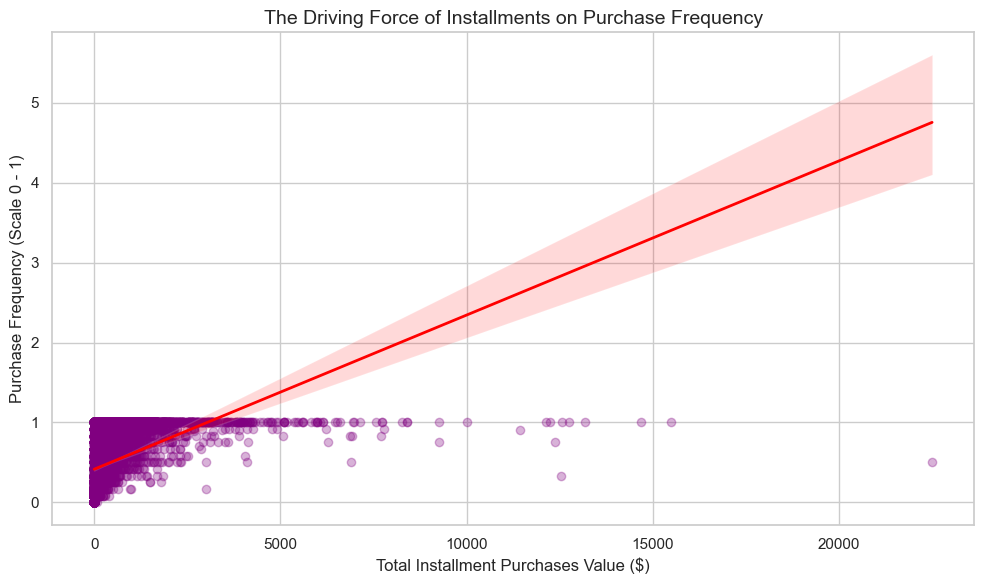

C:\Users\Asus\AppData\Local\Temp\ipykernel_10340\1954290745.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


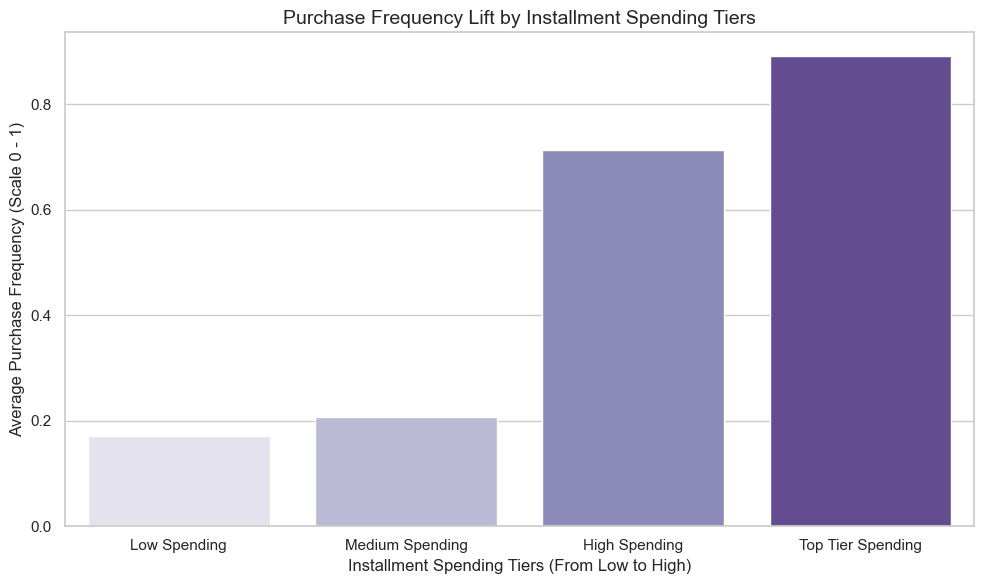

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING ADVANCED VISUALIZATION FOR HYPOTHESIS 3 ---")

# 1. Create a Scatter Plot with a Linear Regression Line (Trend Line)
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x='installments_purchases',
    y='purchases_frequency',
    scatter_kws={'alpha': 0.3, 'color': 'purple'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('The Driving Force of Installments on Purchase Frequency', fontsize=14)
plt.xlabel('Total Installment Purchases Value ($)')
plt.ylabel('Purchase Frequency (Scale 0 - 1)')
plt.tight_layout()
plt.show()

# 2. Alternative: Grouped Bar Chart to show a clear step-up pattern
# We divide installment spending into 4 clear tiers (Quartiles) to see the frequency jump
df['Installment_Tier'] = pd.qcut(
    df['installments_purchases'].rank(method='first'), 
    q=4, 
    labels=['Low Spending', 'Medium Spending', 'High Spending', 'Top Tier Spending']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x='Installment_Tier',
    y='purchases_frequency',
    palette='Purples',
    errorbar=None
)

plt.title('Purchase Frequency Lift by Installment Spending Tiers', fontsize=14)
plt.xlabel('Installment Spending Tiers (From Low to High)')
plt.ylabel('Average Purchase Frequency (Scale 0 - 1)')
plt.tight_layout()
plt.show()